In [2]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Extract the dataset from zip file
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Data extracted successfully")

Mounted at /content/drive
Data extracted successfully


In [3]:
# List files to confirm extraction
os.listdir("/content/data")

['Sample - Superstore.csv']

In [5]:
# Load dataset into a pandas DataFrame
import pandas as pd

df = pd.read_csv("/content/data/Sample - Superstore.csv", encoding="latin1")

# Display first 3 rows to understand structure
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [6]:
# Show column names
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
# Get dataset info (data types, missing values, size)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
# Generate statistical summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
# Analyze total sales by category
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [10]:
# Analyze total profit by category
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


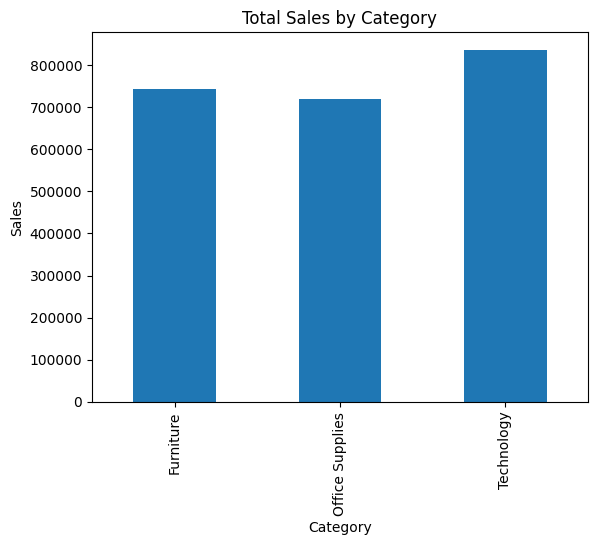

In [11]:
# Visualize sales by category
import matplotlib.pyplot as plt

df.groupby("Category")["Sales"].sum().plot(kind="bar")

plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

In [12]:
# Analyze profit by sub-category (sorted)
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
subcat_profit

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


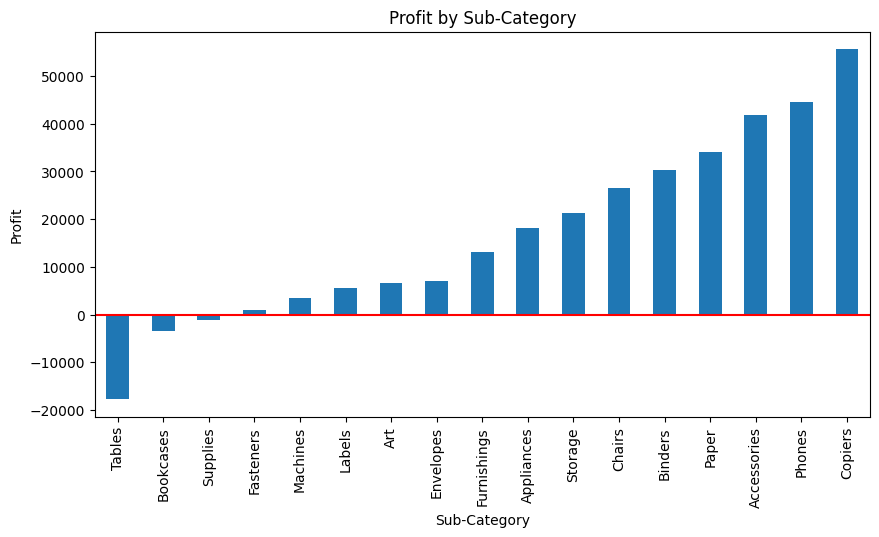

In [13]:
# Visualize profit by sub-category
subcat_profit.plot(kind="bar", figsize=(10,5))

plt.title("Profit by Sub-Category")
plt.ylabel("Profit")
plt.axhline(0, color='red')  # highlight losses
plt.show()

In [14]:
# Sales by region
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


In [15]:
# Profit by region
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


In [16]:
# Analyze average profit for each discount level
df.groupby("Discount")["Profit"].mean()

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


<Axes: xlabel='Discount', ylabel='Profit'>

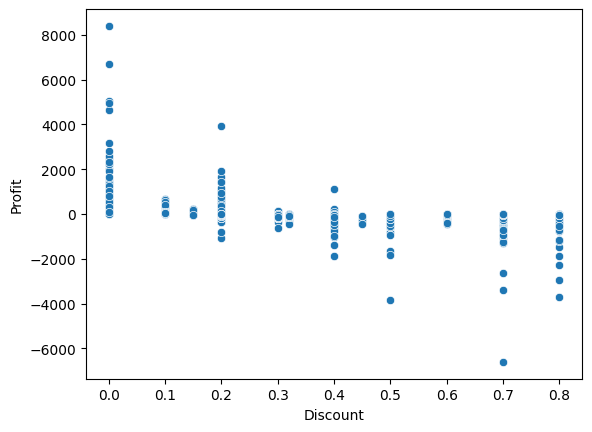

In [17]:
# Visualize relationship between discount and profit
import seaborn as sns

sns.scatterplot(data=df, x="Discount", y="Profit")

In [19]:
# Filter products with negative profit (loss-making)
# Count loss occurrences by sub-category
loss_products = df[df["Profit"] < 0]
loss_products["Sub-Category"].value_counts()

,count
Sub-Category,
Binders,613
Chairs,235
Tables,203
Furnishings,167
Storage,161
Phones,136
Bookcases,109
Accessories,91
Appliances,67


In [20]:
# Identify top 10 customers by total profit
top_customers = df.groupby("Customer Name")["Profit"].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

top_customers

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
Tom Ashbrook,4703.7883
Christopher Martinez,3899.8904
Keith Dawkins,3038.6254
Andy Reiter,2884.6208
